# Phase 2 - Step 8: Model Explainability

This notebook applies SHAP (SHapley Additive exPlanations) to explain global feature importance and individual employee risk attributions without making causal claims.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier

processed_dir = Path("data/processed")
images_dir = Path("docs/images")
images_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(processed_dir / "employee_attrition_processed.csv")

# Feature engineering
df['income_per_year_at_company'] = df['MonthlySalary'] * 12.0 / (df['YearsAtCompany'] + 1.0)
df['promotion_gap_ratio'] = (2026.0 - df['LastPromotionYear']) / (df['YearsAtCompany'] + 1.0)
df['overtime_ratio'] = df['OvertimeHoursPerMonth'] / 160.0
df['leave_utilization'] = df['LeavesTaken'] / 20.0
df['work_life_satisfaction'] = df['WorkLifeBalanceScore'] * df['CustomerSatisfaction']

target_col = 'AttritionRisk'
y = df[target_col].map({'Yes': 1, 'No': 0}).values
drop_cols = ['EmployeeID', 'Name', 'PhoneNumber', 'JoiningDate', 'LastLeaveDate', target_col, 'CountryCode']
X = df.drop(columns=[c for c in drop_cols if c in df.columns])

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols)
    ]
)

# Fit preprocessor and transform features
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

# Extract transformed feature names
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['ohe']
cat_feature_names = cat_encoder.get_feature_names_out(cat_cols).tolist()
all_feature_names = num_cols + cat_feature_names

pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)
xgb_model = XGBClassifier(scale_pos_weight=pos_weight, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_trans, y_train)

# SHAP TreeExplainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test_trans)
shap_values.feature_names = all_feature_names


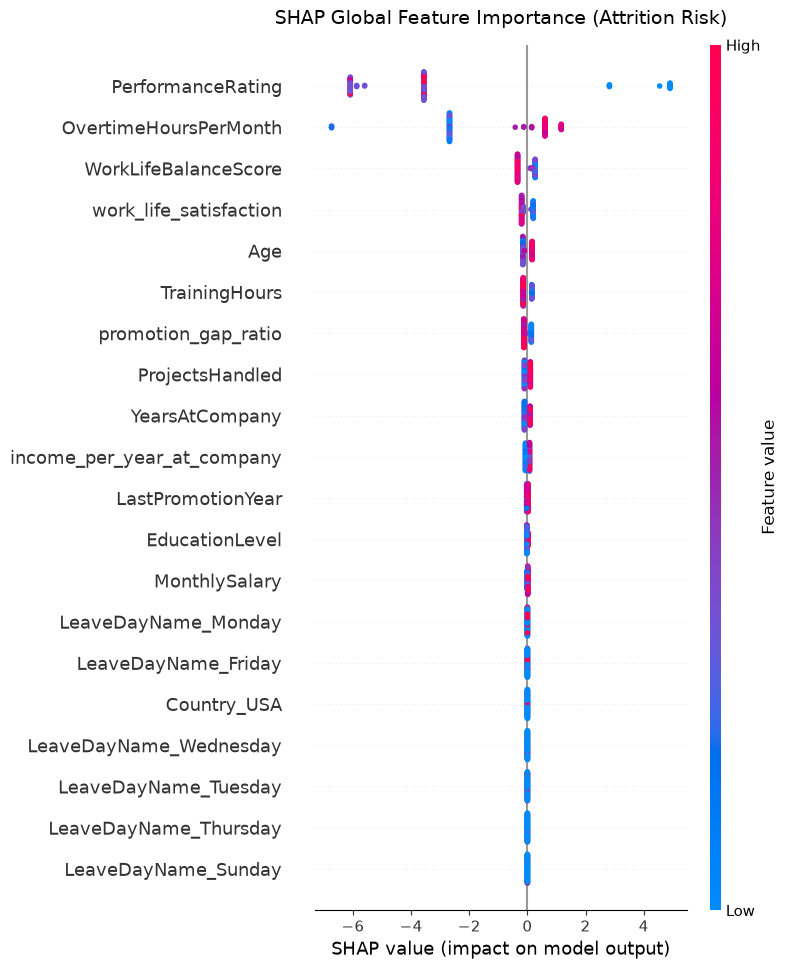

Saved global SHAP summary plot to docs\images\shap_global_summary.png


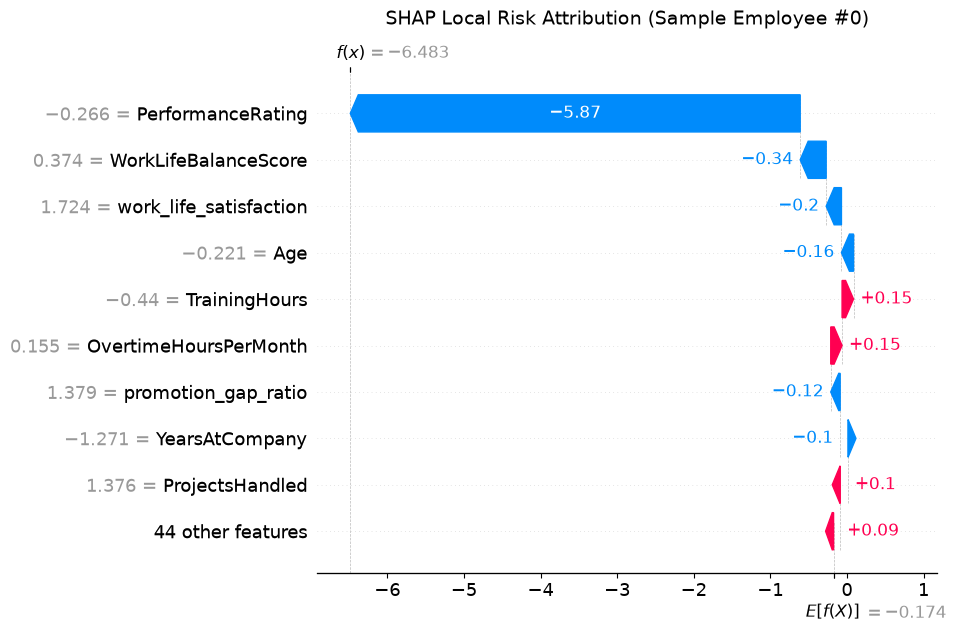

Saved local SHAP waterfall plot to docs\images\shap_local_waterfall.png

EXPLAINABILITY STATEMENT:
SHAP values quantify statistical feature contributions to model predictions under the learned function.
They represent associative attributions, NOT direct causal mechanisms.



In [2]:
# Global Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_trans, feature_names=all_feature_names, show=False)
plt.title("SHAP Global Feature Importance (Attrition Risk)", fontsize=14, pad=15)
global_plot_path = images_dir / "shap_global_summary.png"
plt.savefig(global_plot_path, bbox_inches="tight", dpi=150)
plt.show()
plt.close()
print(f"Saved global SHAP summary plot to {global_plot_path}")

# Local Waterfall Plot for an individual sample
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[0], show=False)
plt.title(f"SHAP Local Risk Attribution (Sample Employee #0)", fontsize=14, pad=15)
local_plot_path = images_dir / "shap_local_waterfall.png"
plt.savefig(local_plot_path, bbox_inches="tight", dpi=150)
plt.show()
plt.close()
print(f"Saved local SHAP waterfall plot to {local_plot_path}")

print("""
EXPLAINABILITY STATEMENT:
SHAP values quantify statistical feature contributions to model predictions under the learned function.
They represent associative attributions, NOT direct causal mechanisms.
""")
